[*********************100%***********************]  1 of 1 completed

Datos descargados:


Price,Date,Open,High,Low,Close,Volume
0,2018-01-02,42.540001,43.075001,42.314999,43.064999,102223600
1,2018-01-03,43.132500,43.637501,42.990002,43.057499,118071600
2,2018-01-04,43.134998,43.367500,43.020000,43.257500,89738400
3,2018-01-05,43.360001,43.842499,43.262501,43.750000,94640000
4,2018-01-08,43.587502,43.902500,43.482498,43.587502,82271200


Resultados de evaluación:


,Modelo,MAE,RMSE,MAPE (%),R2
0,Regresión Lineal,2.039457,2.764707,1.021474,0.987519
1,Random Forest,16.408790,24.587610,7.272421,0.012818
2,XGBoost,17.032231,25.220843,7.566723,-0.038685


Mejor modelo seleccionado: Regresión Lineal


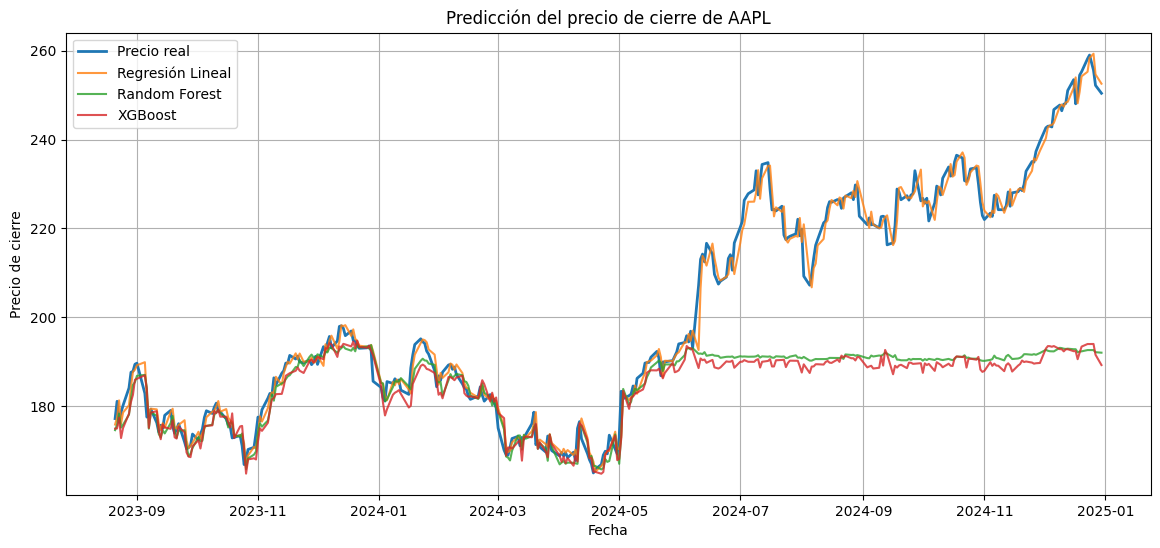

Importancia de variables según Random Forest:


,Variable,Importancia
7,MA_21,0.323762
8,MA_50,0.317599
3,Close,0.125668
2,Low,0.075266
0,Open,0.070680
1,High,0.049926
11,Close_Lag_1,0.019387
6,MA_7,0.006362
12,Close_Lag_2,0.006067
13,Close_Lag_3,0.003010


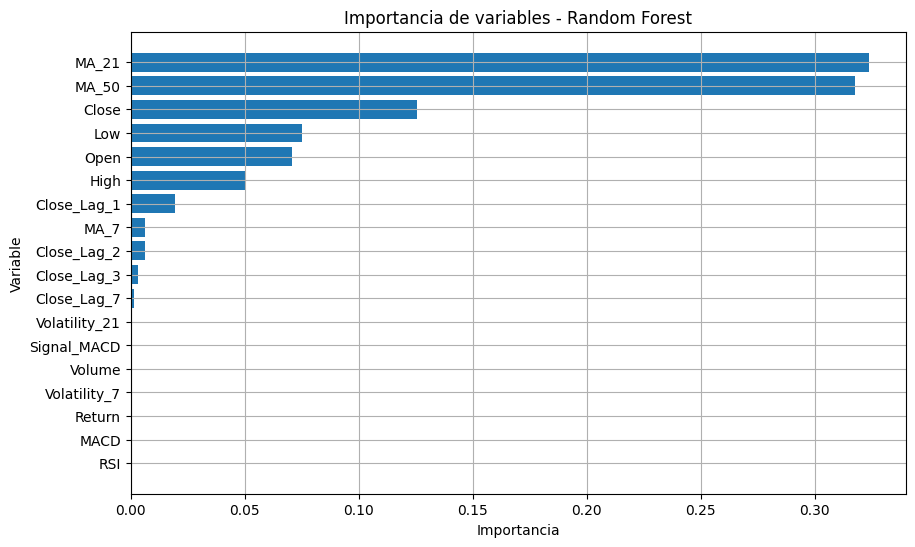

Predicción para los próximos 30 días hábiles de bolsa:


,Fecha,Precio predicho
0,2024-12-31,252.574500
1,2025-01-01,253.516442
2,2025-01-02,254.396745
3,2025-01-03,255.105140
4,2025-01-06,255.690659
5,2025-01-07,256.182082
6,2025-01-08,256.710025
7,2025-01-09,257.470298
8,2025-01-10,258.203001
9,2025-01-13,258.866790


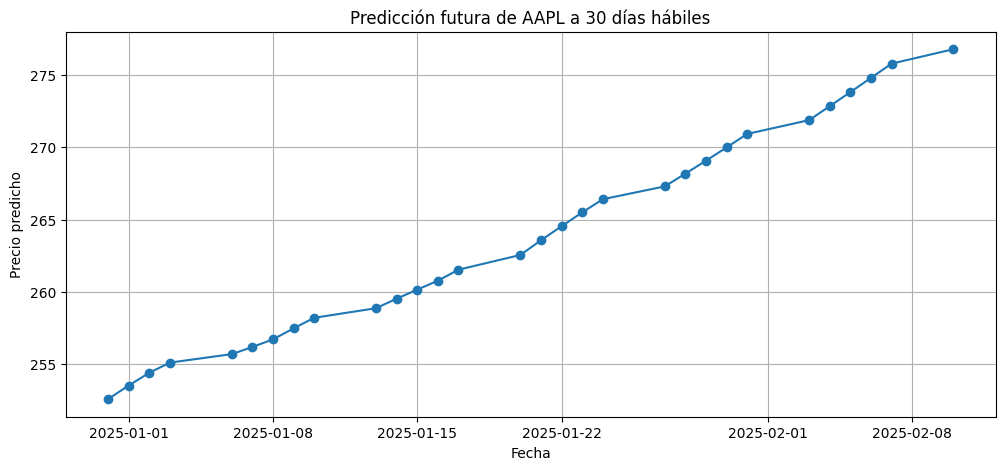

Resultado final para AAPL
Último precio de cierre conocido: 252.20
Días hábiles proyectados: 30
Modelo usado: Regresión Lineal
Precio estimado al día hábil 30: 276.77


In [2]:
# ==========================================
# PROYECTO 1: Predicción de precios de acciones
# Yahoo Finance + Machine Learning
# Predicción a N días hábiles de bolsa
# ==========================================

!pip install yfinance xgboost -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. Parámetros principales
# ==========================================

ticker = "AAPL"          # Cambia por: MSFT, TSLA, NVDA, AMZN, GOOGL, META, JPM, etc.
inicio = "2018-01-01"
fin = "2025-01-01"

dias_habiles = 30        # Aquí pones cuántos días hábiles quieres predecir hacia adelante

# ==========================================
# 2. Descargar datos desde Yahoo Finance
# ==========================================

df = yf.download(ticker, start=inicio, end=fin, auto_adjust=False)

df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]
df = df.dropna()

print("Datos descargados:")
display(df.head())

# ==========================================
# 3. Funciones para indicadores financieros
# ==========================================

def calcular_rsi(data, ventana=14):
    delta = data.diff()
    ganancia = delta.where(delta > 0, 0)
    perdida = -delta.where(delta < 0, 0)

    media_ganancia = ganancia.rolling(window=ventana).mean()
    media_perdida = perdida.rolling(window=ventana).mean()

    rs = media_ganancia / media_perdida
    rsi = 100 - (100 / (1 + rs))

    return rsi


def crear_variables(data):
    data = data.copy()

    data["Return"] = data["Close"].pct_change()

    data["MA_7"] = data["Close"].rolling(window=7).mean()
    data["MA_21"] = data["Close"].rolling(window=21).mean()
    data["MA_50"] = data["Close"].rolling(window=50).mean()

    data["Volatility_7"] = data["Return"].rolling(window=7).std()
    data["Volatility_21"] = data["Return"].rolling(window=21).std()

    data["Close_Lag_1"] = data["Close"].shift(1)
    data["Close_Lag_2"] = data["Close"].shift(2)
    data["Close_Lag_3"] = data["Close"].shift(3)
    data["Close_Lag_7"] = data["Close"].shift(7)

    data["RSI"] = calcular_rsi(data["Close"])

    ema_12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = data["Close"].ewm(span=26, adjust=False).mean()

    data["MACD"] = ema_12 - ema_26
    data["Signal_MACD"] = data["MACD"].ewm(span=9, adjust=False).mean()

    return data

# ==========================================
# 4. Crear variables y variable objetivo
# ==========================================

df = crear_variables(df)

# El modelo aprende a predecir el cierre del siguiente día hábil
df["Target"] = df["Close"].shift(-1)

df = df.dropna()

features = [
    "Open", "High", "Low", "Close", "Volume",
    "Return",
    "MA_7", "MA_21", "MA_50",
    "Volatility_7", "Volatility_21",
    "Close_Lag_1", "Close_Lag_2", "Close_Lag_3", "Close_Lag_7",
    "RSI", "MACD", "Signal_MACD"
]

X = df[features]
y = df["Target"]

# ==========================================
# 5. División temporal entrenamiento/prueba
# ==========================================

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

fechas_test = df["Date"].iloc[split:]

# ==========================================
# 6. Entrenar modelos
# ==========================================

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

modelo_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    objective="reg:squarederror"
)
modelo_xgb.fit(X_train, y_train)
pred_xgb = modelo_xgb.predict(X_test)

# ==========================================
# 7. Evaluación de modelos
# ==========================================

def evaluar_modelo(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

resultados = pd.DataFrame([
    evaluar_modelo("Regresión Lineal", y_test, pred_lr),
    evaluar_modelo("Random Forest", y_test, pred_rf),
    evaluar_modelo("XGBoost", y_test, pred_xgb)
])

print("Resultados de evaluación:")
display(resultados)

# Elegimos automáticamente el mejor modelo según menor RMSE
mejor_modelo_nombre = resultados.sort_values("RMSE").iloc[0]["Modelo"]

if mejor_modelo_nombre == "Regresión Lineal":
    mejor_modelo = modelo_lr
elif mejor_modelo_nombre == "Random Forest":
    mejor_modelo = modelo_rf
else:
    mejor_modelo = modelo_xgb

print("Mejor modelo seleccionado:", mejor_modelo_nombre)

# ==========================================
# 8. Gráfica precio real vs predicción
# ==========================================

plt.figure(figsize=(14, 6))
plt.plot(fechas_test, y_test.values, label="Precio real", linewidth=2)
plt.plot(fechas_test, pred_lr, label="Regresión Lineal", alpha=0.8)
plt.plot(fechas_test, pred_rf, label="Random Forest", alpha=0.8)
plt.plot(fechas_test, pred_xgb, label="XGBoost", alpha=0.8)
plt.title(f"Predicción del precio de cierre de {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 9. Importancia de variables - Random Forest
# ==========================================

importancias = pd.DataFrame({
    "Variable": features,
    "Importancia": modelo_rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("Importancia de variables según Random Forest:")
display(importancias)

plt.figure(figsize=(10, 6))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(True)
plt.show()

# ==========================================
# 10. Predicción a N días hábiles hacia adelante
# ==========================================

df_futuro = df.copy()
predicciones_futuras = []

ultima_fecha = df_futuro["Date"].iloc[-1]

fechas_futuras = pd.bdate_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=dias_habiles
)

for fecha in fechas_futuras:

    ultima_fila = df_futuro.iloc[-1].copy()

    X_futuro = pd.DataFrame([{
        "Open": ultima_fila["Open"],
        "High": ultima_fila["High"],
        "Low": ultima_fila["Low"],
        "Close": ultima_fila["Close"],
        "Volume": ultima_fila["Volume"],
        "Return": ultima_fila["Return"],
        "MA_7": ultima_fila["MA_7"],
        "MA_21": ultima_fila["MA_21"],
        "MA_50": ultima_fila["MA_50"],
        "Volatility_7": ultima_fila["Volatility_7"],
        "Volatility_21": ultima_fila["Volatility_21"],
        "Close_Lag_1": ultima_fila["Close_Lag_1"],
        "Close_Lag_2": ultima_fila["Close_Lag_2"],
        "Close_Lag_3": ultima_fila["Close_Lag_3"],
        "Close_Lag_7": ultima_fila["Close_Lag_7"],
        "RSI": ultima_fila["RSI"],
        "MACD": ultima_fila["MACD"],
        "Signal_MACD": ultima_fila["Signal_MACD"]
    }])

    precio_predicho = mejor_modelo.predict(X_futuro)[0]

    predicciones_futuras.append({
        "Fecha": fecha,
        "Precio predicho": precio_predicho
    })

    nueva_fila = {
        "Date": fecha,
        "Open": precio_predicho,
        "High": precio_predicho,
        "Low": precio_predicho,
        "Close": precio_predicho,
        "Volume": ultima_fila["Volume"],
        "Target": np.nan
    }

    df_futuro = pd.concat(
        [df_futuro, pd.DataFrame([nueva_fila])],
        ignore_index=True
    )

    df_futuro = crear_variables(df_futuro)

predicciones_futuras = pd.DataFrame(predicciones_futuras)

print(f"Predicción para los próximos {dias_habiles} días hábiles de bolsa:")
display(predicciones_futuras)

plt.figure(figsize=(12, 5))
plt.plot(
    predicciones_futuras["Fecha"],
    predicciones_futuras["Precio predicho"],
    marker="o"
)
plt.title(f"Predicción futura de {ticker} a {dias_habiles} días hábiles")
plt.xlabel("Fecha")
plt.ylabel("Precio predicho")
plt.grid(True)
plt.show()

print("==========================================")
print(f"Resultado final para {ticker}")
print("==========================================")
print(f"Último precio de cierre conocido: {df['Close'].iloc[-1]:.2f}")
print(f"Días hábiles proyectados: {dias_habiles}")
print(f"Modelo usado: {mejor_modelo_nombre}")
print(f"Precio estimado al día hábil {dias_habiles}: {predicciones_futuras['Precio predicho'].iloc[-1]:.2f}")